QUESTION 1 - Subquestion 2 

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from collections import Counter


In [21]:
# Load the dataset
file_path = r"C:\Users\Jahanvi B Dinesh\OneDrive\Study Period 6\Advanced Probabilistic Machine Learning\homeworks\HW6\p4dataset2023.txt"
data = pd.read_csv(file_path, sep="\s+", header=None, engine="python")

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Jahanvi B Dinesh\AppData\Local\Temp\ipykernel_22044\2915902031.py:3: SyntaxWarning: invalid escape sequence '\s'
  data = pd.read_csv(file_path, sep="\s+", header=None, engine="python")


In [22]:
# Display the first few rows and shape of the data
print("Loaded data (first 5 rows):")
print(data.head())
print("Data shape:", data.shape)

Loaded data (first 5 rows):
     0     1     2     3     4     5     6     7     8     9      ... 10094  \
0  HG01879     M   ACB     G     G     T     T     A     A     C  ...     T   
1  HG01880     F   ACB     A     A     T     T     A     G     C  ...     G   
2  HG01881     F   ACB     A     A     T     T     A     A     G  ...     G   
3  HG01882     M   ACB     A     A     T     C     A     A     G  ...     G   
4  HG01883     F   ACB     G     A     T     C     G     A     C  ...     G   

  10095 10096 10097 10098 10099 10100 10101 10102 10103  
0     A     T     A     A     T     T     T     G     A  
1     C     T     G     A     T     C     T     G     G  
2     C     T     G     A     T     C     T     G     G  
3     A     T     G     A     T     C     T     G     G  
4     C     T     G     A     T     C     T     G     G  

[5 rows x 10104 columns]
Data shape: (995, 10104)


In [23]:
# Extract metadata
individuals = data.iloc[:, 0]  # Unique IDs
sex = data.iloc[:, 1]          # Sex
population = data.iloc[:, 2]   # Population

In [24]:
# Verify metadata
print("Metadata:")
print("Individuals:", individuals.head())
print("Sex:", sex.head())
print("Population:", population.head())

Metadata:
Individuals: 0    HG01879
1    HG01880
2    HG01881
3    HG01882
4    HG01883
Name: 0, dtype: object
Sex: 0    M
1    F
2    F
3    M
4    F
Name: 1, dtype: object
Population: 0    ACB
1    ACB
2    ACB
3    ACB
4    ACB
Name: 2, dtype: object


In [25]:
# Extract nucleobase columns
genetic_data = data.iloc[:, 3:]

In [26]:
# Compute the mode for each column and convert it to a numpy array
mode_nucleobase = genetic_data.mode(axis=0).iloc[0].to_numpy()


In [27]:
# Initialize the binary matrix
X_binary = np.zeros_like(genetic_data, dtype=int)

In [28]:
# Fill in the binary matrix
for i in range(genetic_data.shape[1]):
    X_binary[:, i] = (genetic_data.iloc[:, i] != mode_nucleobase[i]).astype(int)

In [29]:
# Verify the binary matrix
print("Binary matrix shape:", X_binary.shape)
print("First 5 rows of the binary matrix:")
print(X_binary[:5])

Binary matrix shape: (995, 10101)
First 5 rows of the binary matrix:
[[0 1 0 ... 0 0 1]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [30]:
# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_binary)

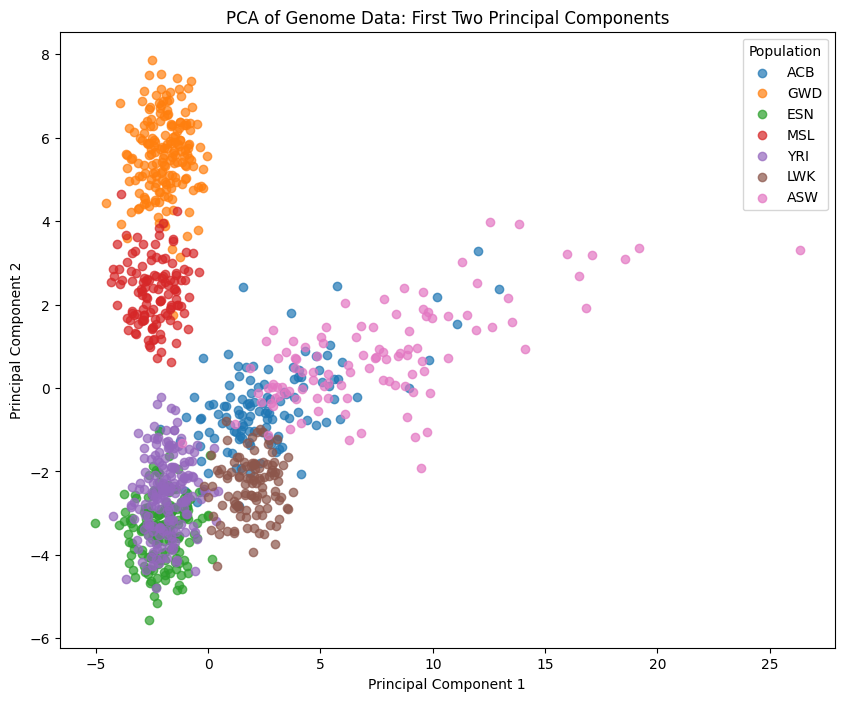

In [31]:
# Create a scatter plot
plt.figure(figsize=(10, 8))
populations = population.unique()
for pop in populations:
    idx = population == pop
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=pop, alpha=0.7)

plt.title("PCA of Genome Data: First Two Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Population")
plt.show()

Question 1 - Subquestion 4

In [32]:
# Perform PCA with 3 components
pca = PCA(n_components=3)
X_pca_3 = pca.fit_transform(X_binary)


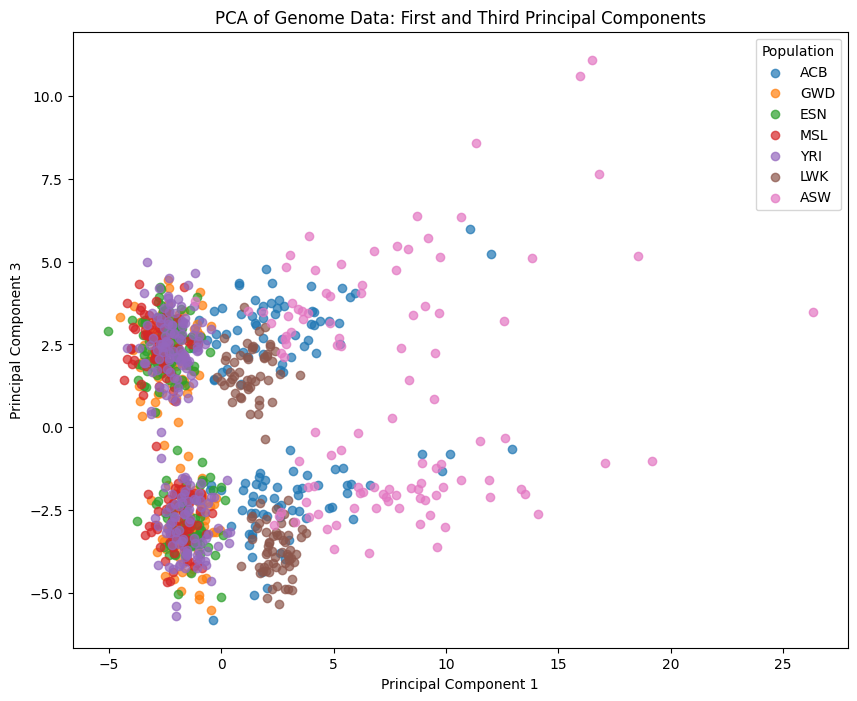

In [33]:
# Scatter plot for PC1 and PC3
plt.figure(figsize=(10, 8))
for pop in populations:
    idx = population == pop
    plt.scatter(X_pca_3[idx, 0], X_pca_3[idx, 2], label=pop, alpha=0.7)

plt.title("PCA of Genome Data: First and Third Principal Components")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.legend(title="Population")
plt.show()

Question 1 - Subquestion 6

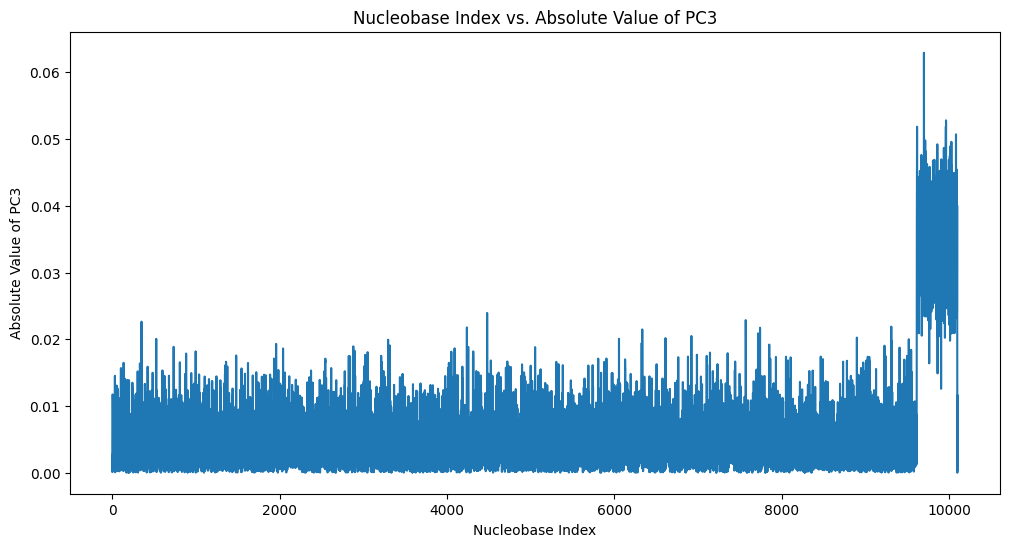

In [34]:
# Retrieve the third principal component
pc3 = pca.components_[2]

# Plot nucleobase index vs. absolute value of PC3
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, len(pc3) + 1), np.abs(pc3))
plt.title("Nucleobase Index vs. Absolute Value of PC3")
plt.xlabel("Nucleobase Index")
plt.ylabel("Absolute Value of PC3")
plt.show()
